In [3]:
import os, random, numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset

from pycocotools.coco import COCO


In [16]:
# Load COCO subset
data_dir = "/kaggle/input/coco-2017-dataset/coco2017"
img_dir = os.path.join(data_dir, "train2017")
ann_file = os.path.join(data_dir, "annotations", "instances_train2017.json")

coco = COCO(ann_file)
img_ids = coco.getImgIds()
sampled_ids = random.sample(img_ids, 100)

loading annotations into memory...
Done (t=16.09s)
creating index...
index created!


In [20]:
valid_ids = []
for img_id in sampled_ids:
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)
    mask = np.zeros((128, 128), dtype=np.uint8)
    for ann in anns:
        rle = coco.annToMask(ann)
        rle = cv2.resize(rle, (128, 128), interpolation=cv2.INTER_NEAREST)
        mask = np.maximum(mask, rle)
    if mask.sum() > 0:
        valid_ids.append(img_id)

small_img_ids = random.sample(valid_ids, min(5, len(valid_ids)))

In [21]:
# Dataset class
class CocoSegDataset(Dataset):
    def __init__(self, coco, img_dir, img_ids, target_size=(128,128)):
        self.coco = coco
        self.img_dir = img_dir
        self.img_ids = img_ids
        self.target_size = target_size
        self.transform = T.ToTensor()

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        image = Image.open(img_path).convert("RGB").resize(self.target_size)
        mask = np.zeros(self.target_size, dtype=np.uint8)
        for ann in anns:
            rle = self.coco.annToMask(ann)
            rle = cv2.resize(rle, self.target_size)
            mask = np.maximum(mask, rle)

        image = self.transform(image)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)  # ✅ No division
        return image, mask

In [22]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = self.conv_block(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = self.conv_block(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(128, 64)

        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))
        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return self.out(d1)

# Weight initialization
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

In [23]:
# Metrics
def iou(pred,true,threshold=0.5):
    pred_bin = (pred>threshold).float()
    true_bin = (true>0.5).float()
    inter = (pred_bin*true_bin).sum()
    union = pred_bin.sum()+true_bin.sum()-inter + 1e-7
    return (inter/union).item()

def dice(pred,true,threshold=0.5):
    pred_bin = (pred>threshold).float()
    true_bin = (true>0.5).float()
    inter = (pred_bin*true_bin).sum()
    return (2*inter/(pred_bin.sum()+true_bin.sum()+1e-7)).item()


In [24]:
# Training loop
def train_model(optimizer_name, train_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet().to(device)
    model.apply(init_weights)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = {
        'SGD': optim.SGD(model.parameters(), lr=0.01),
        'Adam': optim.Adam(model.parameters(), lr=0.001),
        'RMSprop': optim.RMSprop(model.parameters(), lr=0.001)
    }[optimizer_name]

    train_losses = []
    for epoch in range(5):
        model.train()
        epoch_loss = 0
        for img, mask in train_loader:
            img, mask = img.to(device), mask.to(device)
            optimizer.zero_grad()
            output = model(img)
            loss = criterion(output, mask)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))
        print(f"{optimizer_name} Epoch {epoch+1}: Loss = {train_losses[-1]:.4f}")
    return model, train_losses


SGD Epoch 1: Loss = 0.8916
SGD Epoch 2: Loss = 0.8124
SGD Epoch 3: Loss = 0.7382
SGD Epoch 4: Loss = 0.7363
SGD Epoch 5: Loss = 0.6827
Adam Epoch 1: Loss = 0.7010
Adam Epoch 2: Loss = 0.5469
Adam Epoch 3: Loss = 0.4835
Adam Epoch 4: Loss = 0.3983
Adam Epoch 5: Loss = 0.3379
RMSprop Epoch 1: Loss = 0.8836
RMSprop Epoch 2: Loss = 0.6161
RMSprop Epoch 3: Loss = 0.6121
RMSprop Epoch 4: Loss = 0.5940
RMSprop Epoch 5: Loss = 0.5413


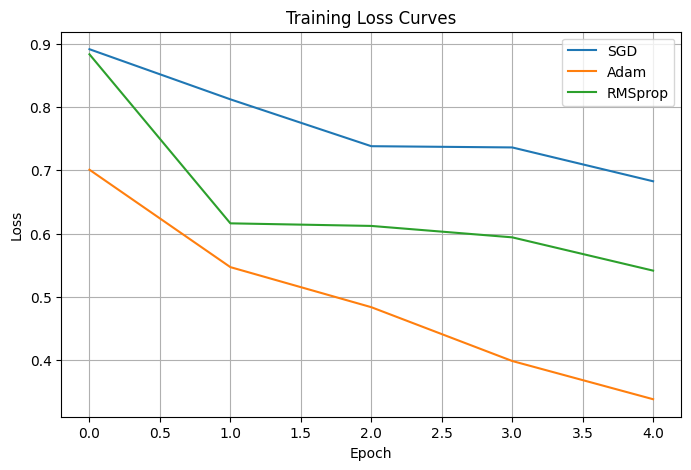

In [25]:
# Train all optimizers
dataset = CocoSegDataset(coco, img_dir, small_img_ids)
train_loader = DataLoader(dataset, batch_size=1, shuffle=True)

loss_dict = {}
models = {}
for opt in ['SGD', 'Adam', 'RMSprop']:
    model, losses = train_model(opt, train_loader)
    models[opt] = model
    loss_dict[opt] = losses

# Plot loss curves
plt.figure(figsize=(8,5))
for opt in loss_dict:
    plt.plot(loss_dict[opt], label=opt)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid()
plt.show()


🔍 Showing predictions for optimizer: SGD


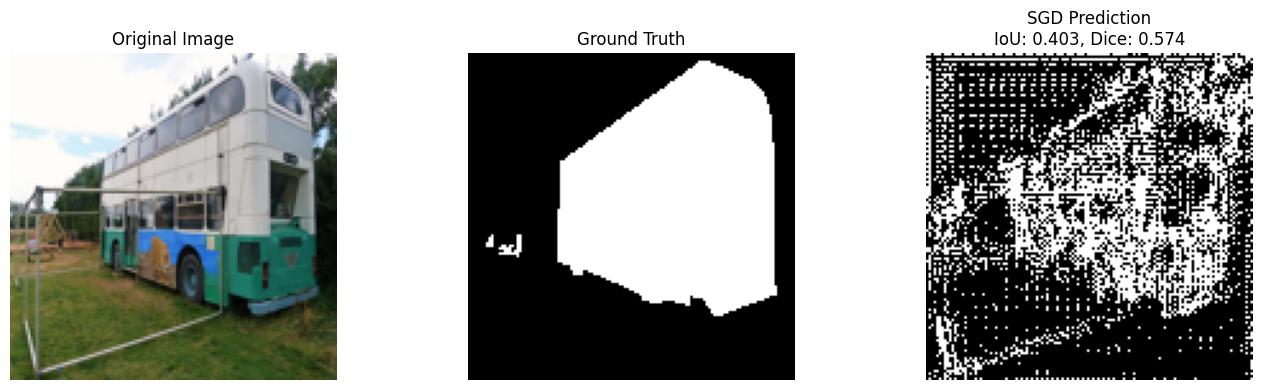

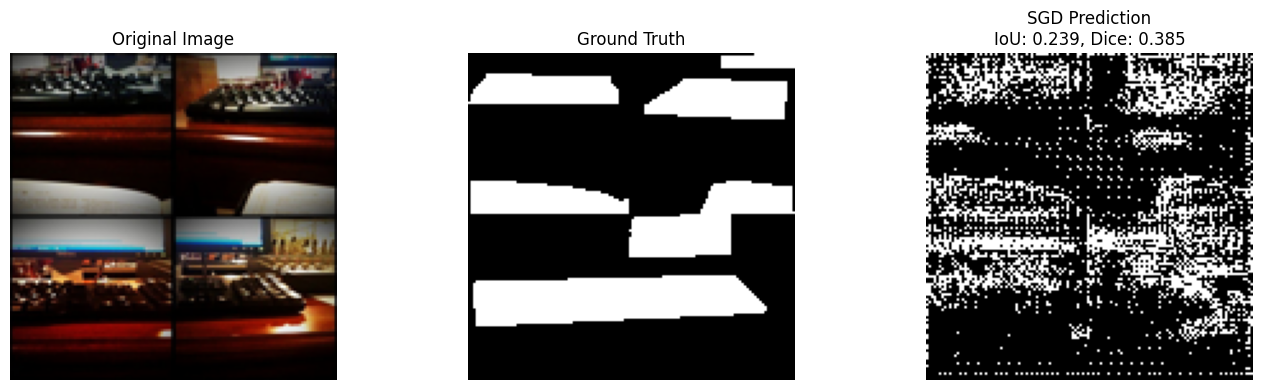

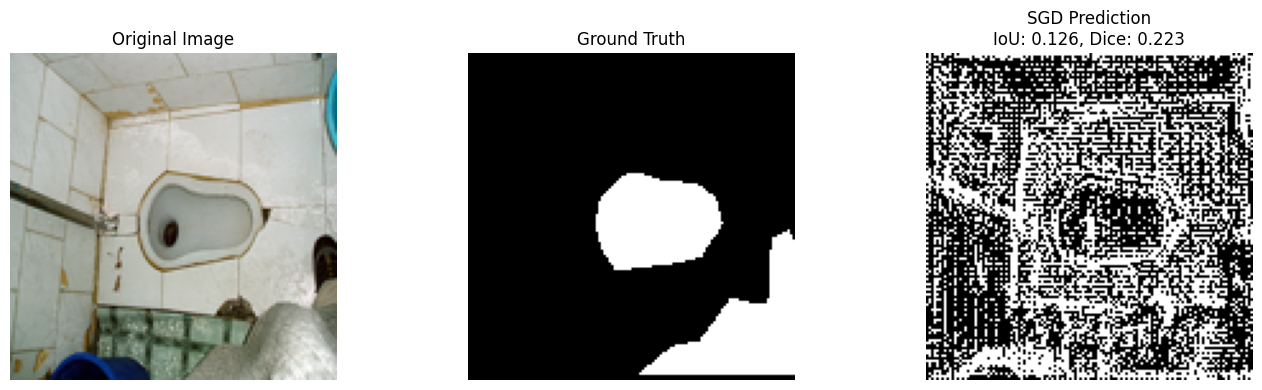

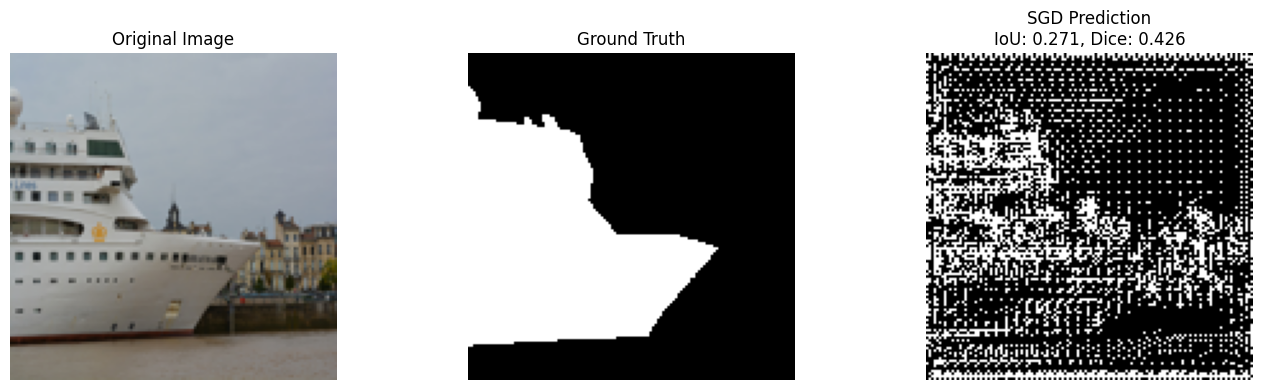

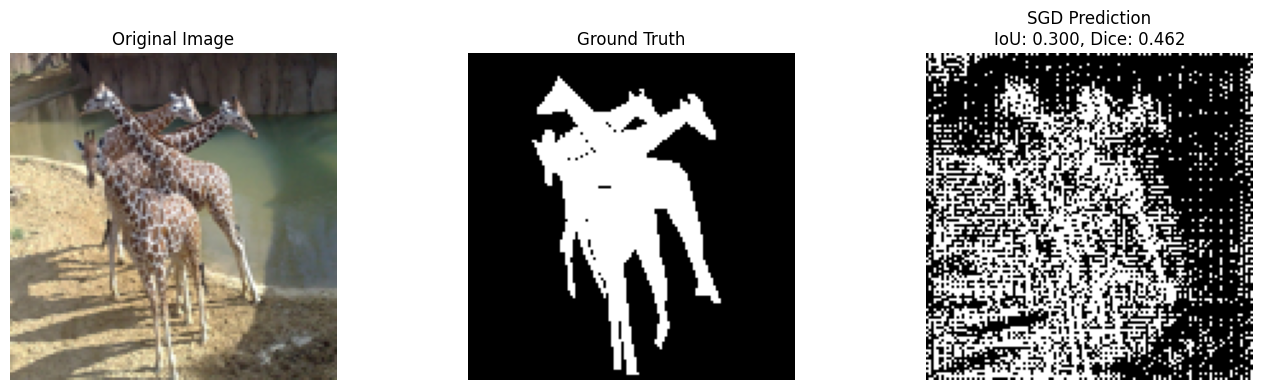


🔍 Showing predictions for optimizer: Adam


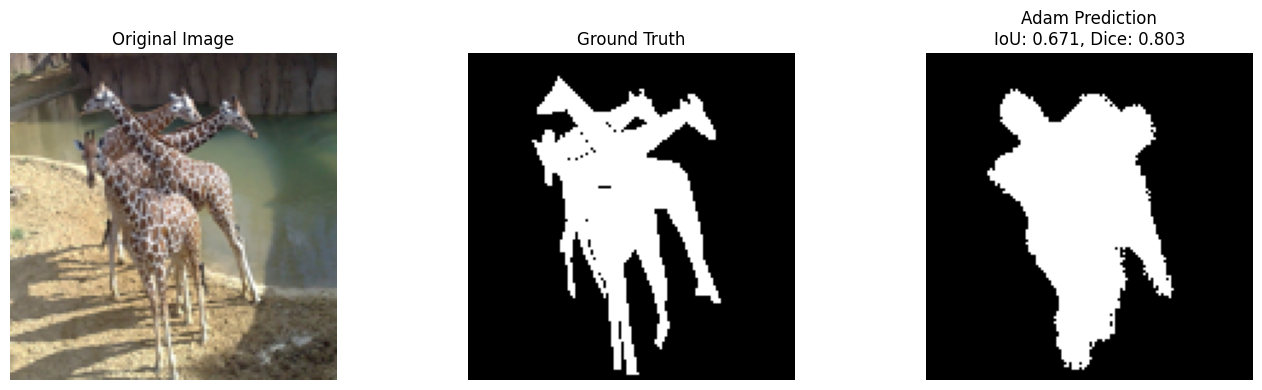

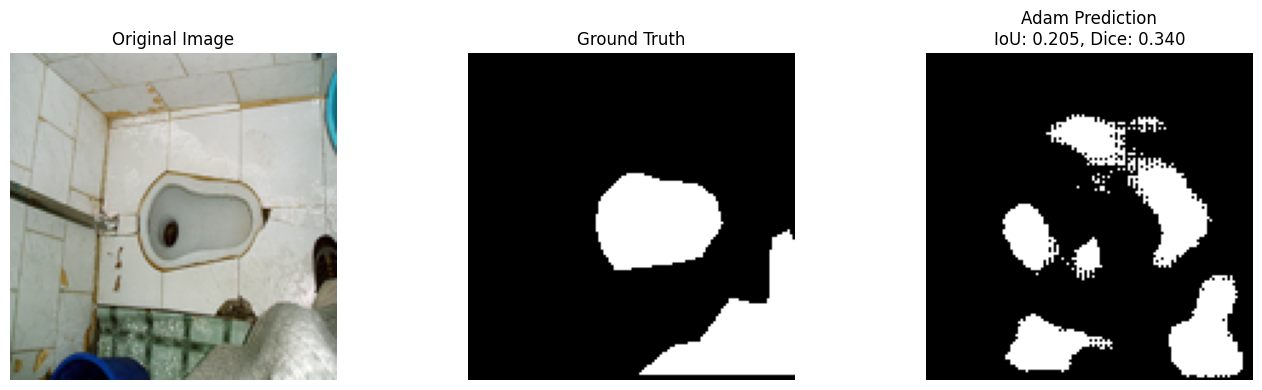

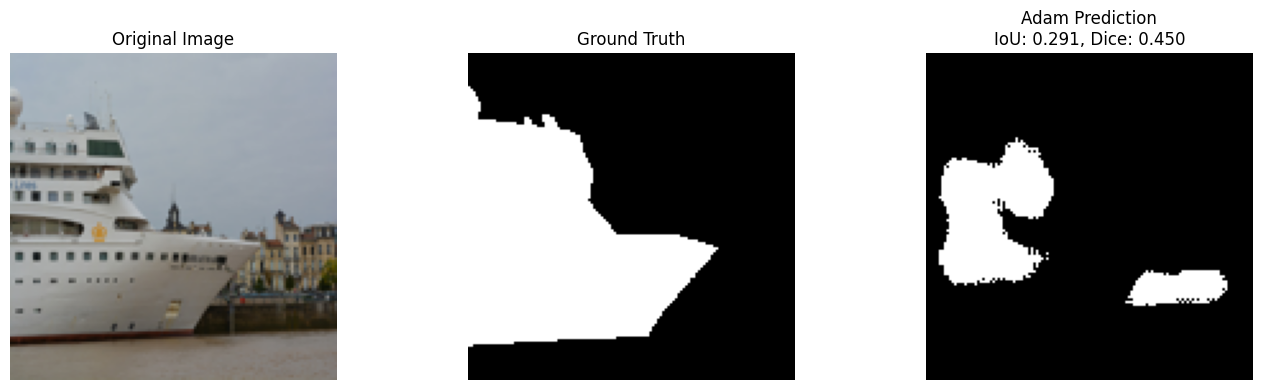

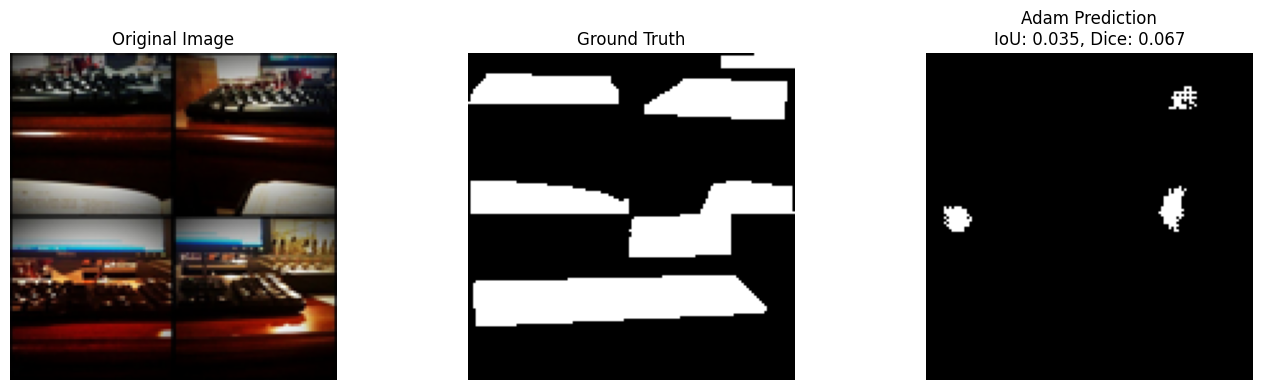

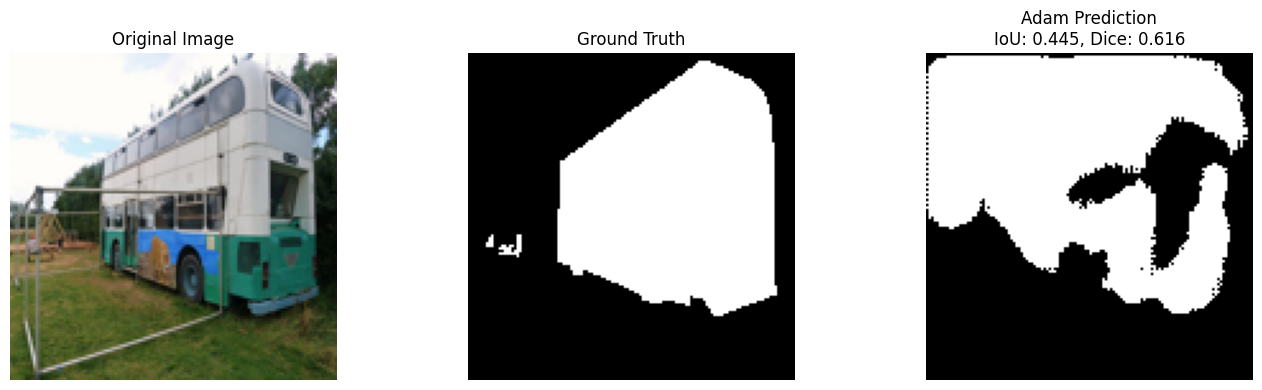


🔍 Showing predictions for optimizer: RMSprop


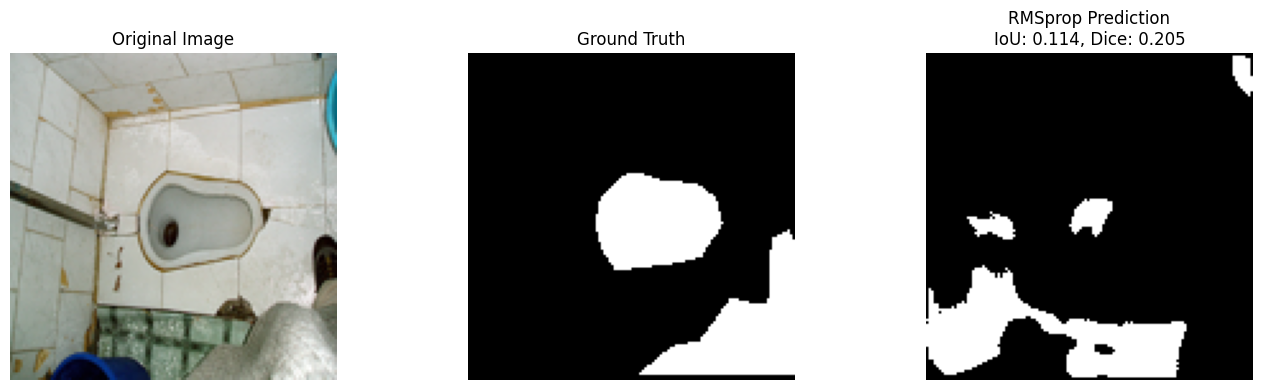

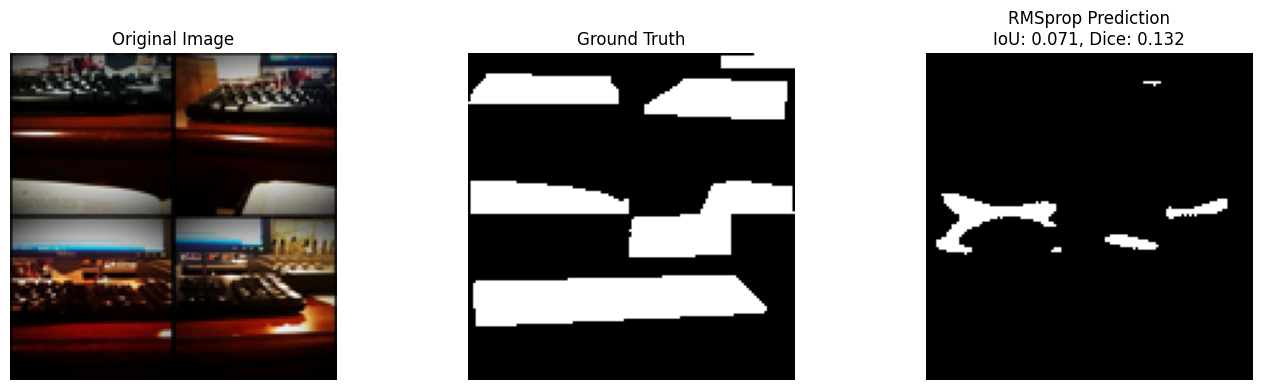

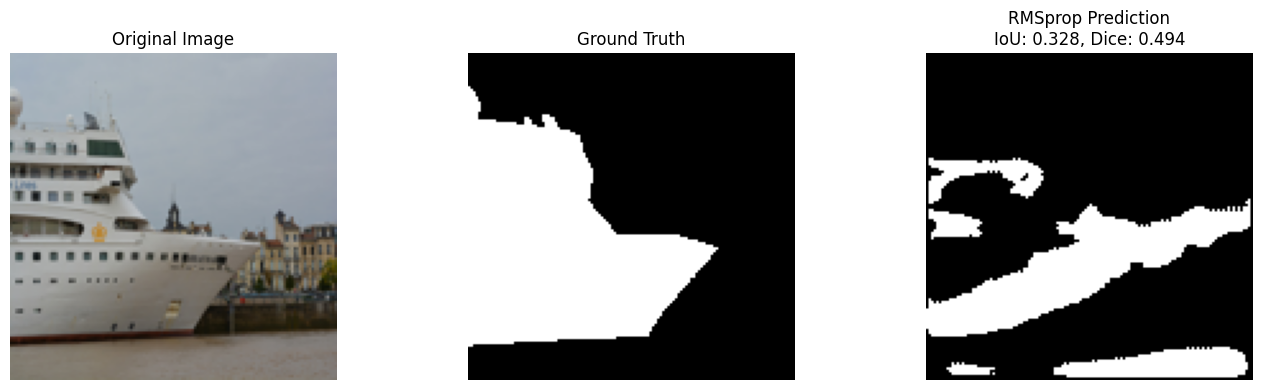

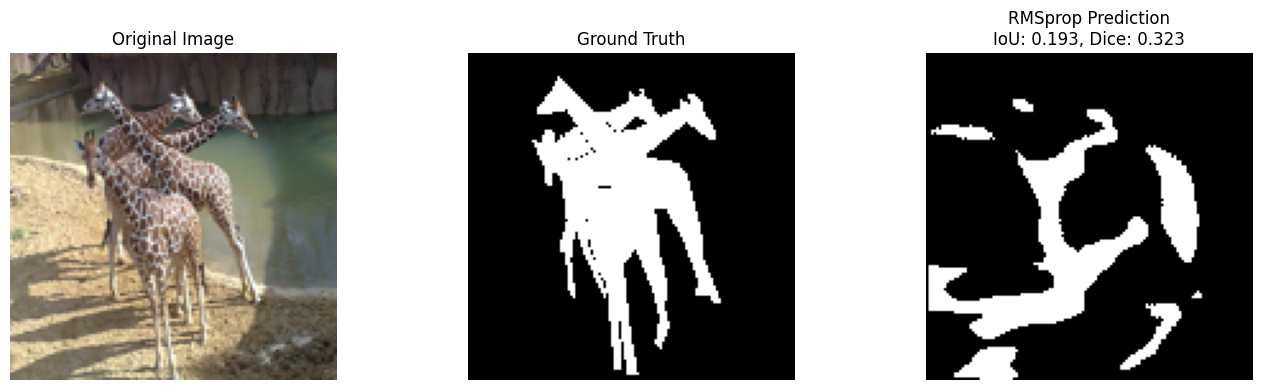

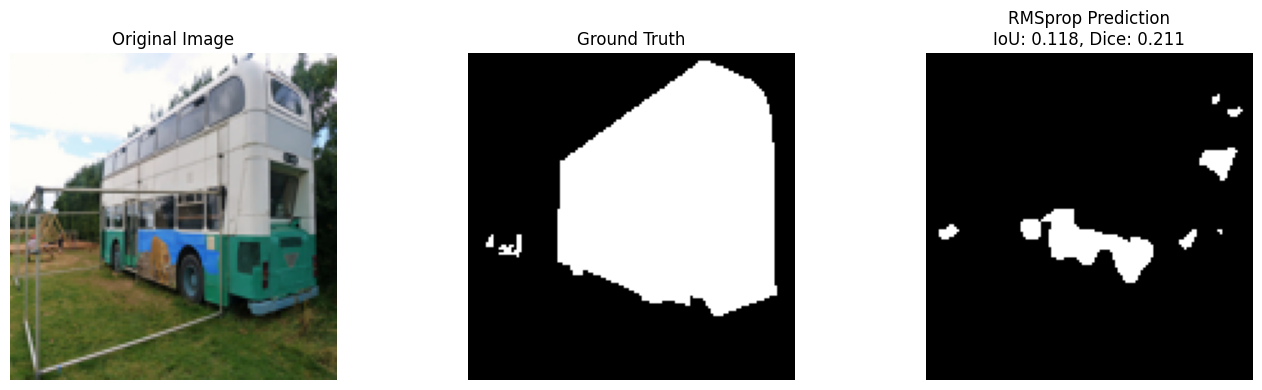

In [26]:
# Show predictions
def show_predictions_with_metrics(models_dict, dataloader, num_samples=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    for opt_name, model in models_dict.items():
        print(f"\n🔍 Showing predictions for optimizer: {opt_name}")
        model.eval()
        count = 0
        with torch.no_grad():
            for images, masks in dataloader:
                images, masks = images.to(device), masks.to(device)
                preds = torch.sigmoid(model(images))
                preds_bin = (preds > 0.5).float()

                for i in range(images.shape[0]):
                    if count >= num_samples:
                        break
                    iou_score = iou(preds_bin[i], masks[i])
                    dice_score = dice(preds_bin[i], masks[i])

                    fig, axs = plt.subplots(1, 3, figsize=(14, 4))
                    axs[0].imshow(images[i].permute(1, 2, 0).cpu())
                    axs[0].set_title("Original Image")
                    axs[1].imshow(masks[i][0].cpu(), cmap='gray')
                    axs[1].set_title("Ground Truth")
                    axs[2].imshow(preds_bin[i][0].cpu(), cmap='gray')
                    axs[2].set_title(f"{opt_name} Prediction\nIoU: {iou_score:.3f}, Dice: {dice_score:.3f}")
                    for ax in axs: ax.axis('off')
                    plt.tight_layout()
                    plt.show()
                    count += 1
show_predictions_with_metrics(models, train_loader, num_samples=5)

In [27]:
# Final metrics
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nValidation Metrics:")
for opt, model in models.items():
    model.eval()
    with torch.no_grad():
        iou_scores, dice_scores = [], []
        for img, mask in train_loader:
            img, mask = img.to(device), mask.to(device)
            output = torch.sigmoid(model(img))
            iou_scores.append(iou(output, mask))
            dice_scores.append(dice(output, mask))
        mean_iou = np.mean(iou_scores)
        mean_dice = np.mean(dice_scores)
        print(f"{opt}: Mean IoU = {mean_iou:.4f}, Dice = {mean_dice:.4f}")


Validation Metrics:
SGD: Mean IoU = 0.2675, Dice = 0.4141
Adam: Mean IoU = 0.3291, Dice = 0.4552
RMSprop: Mean IoU = 0.1647, Dice = 0.2730
